# **Exploratory Data Analysis of the Pima Indians Diabetes Dataset**

This project explores the Pima Indians Diabetes dataset using Python for data cleaning and exploratory data analysis. Key steps include handling missing clinical values, validating variable definitions, and visualizind relationships between glucose, BMI, parity, and diabetes outcome.

**Tools:** Python, Pandas, Numpy, Matplotlib, Seaborn.

**Skills:** Data cleaning, Exploratory data analysis (EDA), Data Visualization.

**Author**: Ruth Gezahegn

**Date**: Dec, 2025

**Dataset**: Pima Indians Diabetes Dataset

**Objective**

The objective of this project is to perform a basic exploratory data analysis(EDA) in order to:

* Understand the distribution of key clinical variables.
* Clean the dataset.
* Explore their relationship with diabetes outcome.
* Practice data cleaning, visualization, and interpretation skills.

This analysis focuses on clarity, correctness, and clinical relevance rather than model buliding.

# **Dataset Description**

The Pima Indians Diabetes dataset contains medical and demographic information for adult female patients of Pima Indian heritage. The dataset is commonly used for introductory data analysis and machine learning tasks in healthcare.

**Important Clarifications:**

* Glucose represents fasting plasma glucose level measured in mg/dl.
* Blood pressure represents diastolic blod pressure in mmHg. Systolic blood pressure is not included in this dataset.
* Outcome is a binary variable: 0 = No diabetes, 1 = Diabetes.

In [1]:
import pandas as pd
df = pd.read_csv('/kaggle/input/review/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# **Data Cleaning**

In [2]:
#checking for missing values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

The missing datas still exist but are encoded as 0 instead of Nan. This poses another data cleaning task.The columns where 0 would be physiologically impossible are: Glucose, BloodPressure, SkinThickness, Insulin, BMI and Age. So these invalid zeros should be replaced with Nan and cleaned accordingly.

In [3]:
import numpy as np

columns_with_zero_as_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Age']

df[columns_with_zero_as_missing] = df[columns_with_zero_as_missing].replace(0, np.nan)
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Now that the invalid zero values are identified, they will be replaced with the median of their respective columns so that the distribution of the dataset is intact.

In [4]:
for col in columns_with_zero_as_missing:
    df.loc[:, col]=df[col].fillna(df[col].median())

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


The remaining step in the data cleaning would be removing duplicate rows, if any.

In [5]:
print("Before:", df.shape)
df = df.drop_duplicates()
print("After:", df.shape)

Before: (768, 9)
After: (768, 9)


Since the shape does not cahnge before and after removing the duplicates there are no duplicated rows.

# **Data Visualization**

**Distribution of Blood Glucose Level**

Histogram will be used to depict the distribution of Blood Glucose level in this dataset.

In [6]:
def glucose_category(value):
    if value < 70:
        return'Low'
    elif 70 <= value < 126:
        return'Normal'
    else:
        return'High'
df['GlucoseLevel']=df['Glucose'].apply(glucose_category)

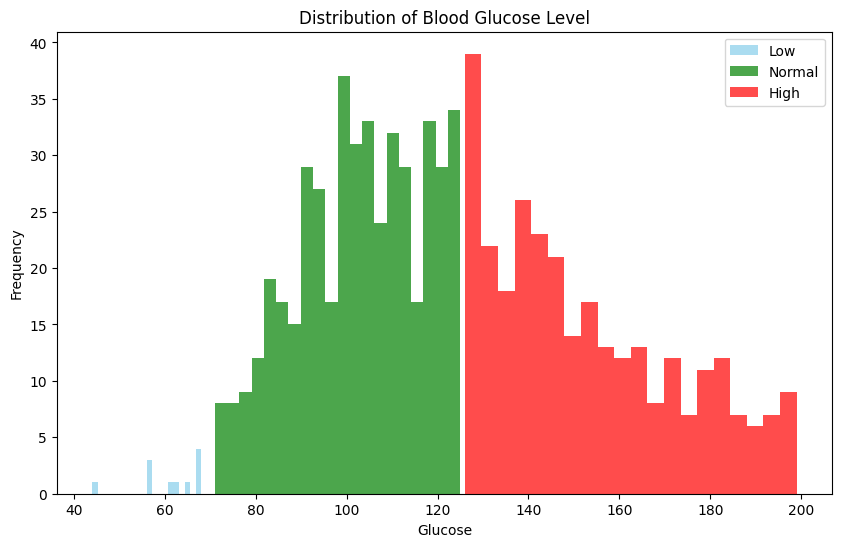

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
colors={'Low':'skyblue', 'Normal':'green', 'High':'red'}
for category, color in colors.items():
    subset=df[df['GlucoseLevel']==category]
    plt.hist(subset['Glucose'], bins=20, alpha=0.7, color=color, label=category)
plt.title('Distribution of Blood Glucose Level')
plt.xlabel('Glucose')
plt.ylabel('Frequency')
plt.legend()
plt.show()

This histogram shows the distribution of fasting blood glucose levels categorized according to standard reference ranges. Most observations cluster around the normal to elevated range, with fewer individuals having low glucose levels. This provides an overview of the glucose profile of the study population and helps identify skewness and potential outliers.

**BMI vs Diabetes Outcome**

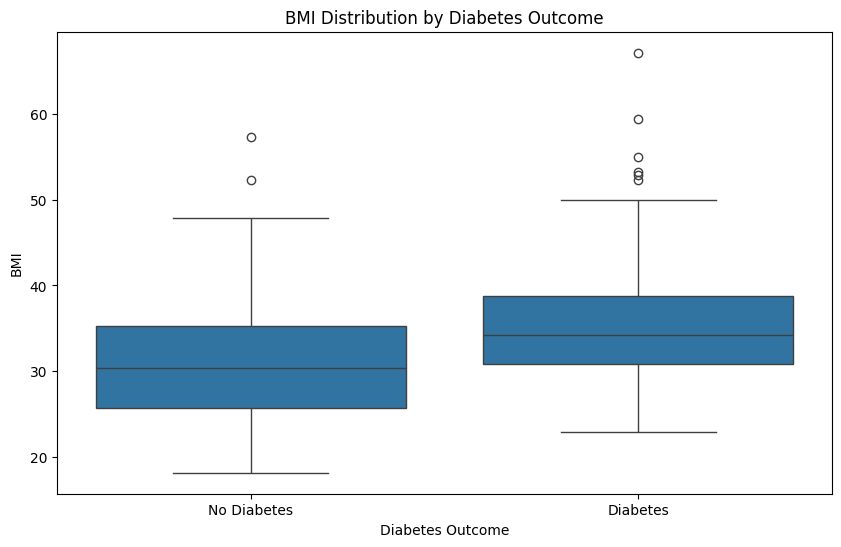

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(x='Outcome', y='BMI', data=df)
plt.title('BMI Distribution by Diabetes Outcome')
plt.xlabel('Diabetes Outcome')
plt.ylabel('BMI')
plt.xticks([0,1],['No Diabetes', 'Diabetes'])
plt.show()

BMI is noticeably high in individuals with diabetes. This supports the well established association between BMI and the risk of developing diabetes.

**Relationship between Parity vs diabetes outcome**

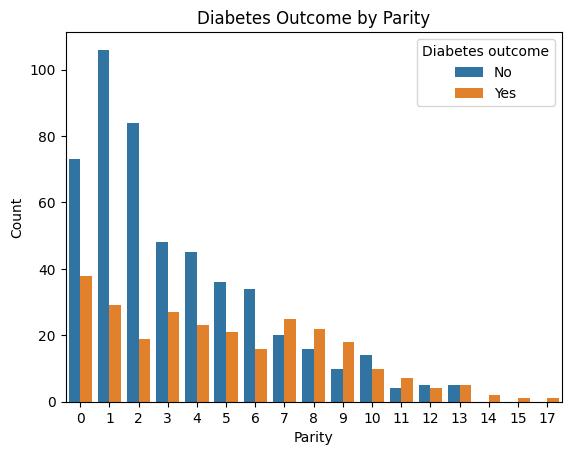

In [9]:
sns.countplot(x='Pregnancies', hue='Outcome', data=df)
plt.xlabel('Parity')
plt.ylabel('Count')
plt.title('Diabetes Outcome by Parity')
plt.legend(title='Diabetes outcome', labels=['No','Yes'])
plt.show()

This plot compares the frequency of diabetes across different parity groups. While some variations show that there is a postive relationship between the two, parity alone doesn't appear to strongly distinguish diabetic from non diabetic individuals, suggesting it may act as a contributing factor rather than a primary risk factor.

# **Conclusion** 

This exploratory analysis highlights key relationshios between diabets and several clinical variables:

* Elevated fasting glucose levels are common among diabetic patients.
* Higher BMI is associated with diabetes presence.
* Increased parity may act as a contributing factor in diabetes prevalence, showing a relation between obstertrics history of the individual and diabetes status.

# **Next Steps**

* Perform correlation analysis and statistical testing.
* Apply basic machine learning models.
* Explore additional datasets that include systolic blood pressure and OGTT values for richer clinical analysis.